# **HW12: Dimensionality Reduction**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*


# **t-SNE and Word Embeddings Visualization**

In this notebook exercise, we will explore **t-SNE (t-Distributed Stochastic Neighbor Embedding)**, a powerful non-linear dimensionality reduction technique that is particularly well-suited for visualizing high-dimensional data.

## **Why t-SNE for Word Embeddings?**

Word embeddings like GloVe (Global Vectors for Word Representation) capture semantic relationships between words in high-dimensional space (typically 50-300 dimensions). However, visualizing these relationships requires reducing them to 2D or 3D.

**t-SNE advantages**:
- **Preserves local structure**: Words with similar meanings cluster together
- **Non-linear**: Captures complex relationships better than linear methods like PCA
- **Excellent for visualization**: Produces clear, interpretable 2D/3D plots

## **What is t-SNE?**

t-SNE is an unsupervised learning technique that:
1. Computes pairwise similarities between points in high-dimensional space
2. Computes pairwise similarities in low-dimensional space
3. Minimizes the difference between these similarities using gradient descent
4. Emphasizes preserving local neighborhoods over global structure

Unlike PCA, t-SNE is **non-linear** and focuses on keeping similar items close together rather than maximizing variance.

## **Objectives**

In this exercise, you will:
1. Load pre-trained GloVe word embeddings using Gensim
2. Select trading commodity words
3. Extract their high-dimensional vector representations
4. Apply t-SNE to reduce to 2D
5. Visualize semantic relationships between commodity categories

## **Import Libraries**

Let's start by importing the necessary libraries for our analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import gensim.downloader as api

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

# Load GloVe embeddings using Gensim
print("Loading GloVe embeddings (glove-wiki-gigaword-50)...")
print("This will download ~65MB on first run...")
model = api.load('glove-wiki-gigaword-50')
print(f"Loaded model with {len(model)} word vectors")
print(f"Vector dimension: {model.vector_size}")

Loading GloVe embeddings (glove-wiki-gigaword-50)...
This will download ~65MB on first run...
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded model with 400000 word vectors
Vector dimension: 50


## **Load GloVe Word Embeddings with Gensim**

We'll use pre-trained GloVe word embeddings loaded through Gensim's downloader API. These embeddings are trained on Wikipedia and Gigaword corpus and capture semantic relationships between words.

**Key advantages of Gensim + GloVe**:
- **Small size**: Only ~65MB for 50-dimensional vectors
- **Easy installation**: Automatic download via Gensim API
- **Good quality**: Trained on large corpus, captures semantic relationships well
- **50 dimensions**: Good balance between expressiveness and computational efficiency

The `glove-wiki-gigaword-50` model includes word vectors for 400,000 common English words, which we'll use to represent trading commodities.

## **Define Trading Commodity Words**

Let's select a diverse set of commodities that are actively traded in global markets, organized by category.

In [2]:
# Define trading commodity words by category
commodity_words = {
    'Precious Metals': ['gold', 'silver', 'platinum', 'palladium', 'rhodium', 'iridium', 'copper', 'bronze'],
    'Energy': ['oil', 'gas', 'coal', 'gasoline', 'diesel', 'propane', 'uranium', 'petroleum', 'ethanol', 'electricity'],
    'Grains': ['wheat', 'corn', 'rice', 'oats', 'barley', 'soybeans', 'soybean', 'sorghum'],
    'Softs': ['coffee', 'sugar', 'cocoa', 'cotton', 'orange', 'rubber', 'lumber', 'wool', 'silk'],
    'Livestock': ['cattle', 'hogs', 'pork', 'beef', 'chicken', 'milk', 'butter', 'cheese'],
    'Industrial Metals': ['aluminum', 'steel', 'iron', 'zinc', 'lead', 'nickel', 'tin', 'cobalt'],
    'Chemicals': ['ammonia', 'sulfur', 'phosphate', 'nitrogen', 'potash', 'methanol'],
    'Fibers': ['polyester', 'nylon', 'rayon', 'hemp', 'jute', 'flax']
}

# Flatten the dictionary to get all words and their categories
all_words = []
word_categories = {}
for category, words in commodity_words.items():
    for word in words:
        all_words.append(word)
        word_categories[word] = category
categories = list(commodity_words.keys())

print(f"Total number of commodity words: {len(all_words)}")
print(f"\nCategories: {categories}")
print(f"\nSample words: {all_words[:10]}")

Total number of commodity words: 63

Categories: ['Precious Metals', 'Energy', 'Grains', 'Softs', 'Livestock', 'Industrial Metals', 'Chemicals', 'Fibers']

Sample words: ['gold', 'silver', 'platinum', 'palladium', 'rhodium', 'iridium', 'copper', 'bronze', 'oil', 'gas']


### **Plot Embeddings**

In [3]:
def plot_embeddings(title: str, words_to_plot, word_vectors_2d, word_categories):
    plt.figure(figsize=(16, 12))

    # Create a color map for categories
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
    category_colors = {cat: colors[i] for i, cat in enumerate(categories)}

    # Plot each word
    for i, word in enumerate(words_to_plot):
        category = word_categories[word]
        x, y = word_vectors_2d[i]
        
        plt.scatter(x, y, c=[category_colors[category]], s=300, alpha=0.6, edgecolors='black', linewidth=1)
        plt.annotate(word, (x, y), fontsize=24, alpha=0.8, ha='center')

    # Create legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=category_colors[cat], 
                                markersize=10, label=cat, alpha=0.6)
                    for cat in categories]
    plt.legend(handles=legend_elements, loc='best', fontsize=11, title='Commodity Categories')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Extract Word Vectors**

Extract the GloVe word vectors for our commodity words using the Gensim model.

- Create a dictionary to store the vectors
- Loop through all_words and check if each word exists in the model
- If it exists, add the vector to the dictionary
- Print statistics about found and missing words

In [4]:
# Write your code here
word_vector_dict = {}
missing_words = []

for word in all_words:
    if word in model:
        word_vector_dict[word] = model[word]
    else:
        missing_words.append(word)
        print(f"Warning: '{word}' not found in GloVe vocabulary")

valid_words = list(word_vector_dict.keys())
word_vectors = np.array(list(word_vector_dict.values()))

print(f"\nFound embeddings for {len(valid_words)} words")
print(f"Missing embeddings for {len(missing_words)} words")
print(f"Word vectors shape: {word_vectors.shape}")


Found embeddings for 63 words
Missing embeddings for 0 words
Word vectors shape: (63, 50)


## **Explore Word Vector Properties**

Let's examine some properties of our word vectors to understand what we're working with.

In [5]:
# Display statistics about the word vectors
print("Word Vector Statistics:")
print(f"Mean: {word_vectors.mean():.4f}")
print(f"Std: {word_vectors.std():.4f}")
print(f"Min: {word_vectors.min():.4f}")
print(f"Max: {word_vectors.max():.4f}")

# Show an example vector
print(f"\nExample: Vector for '{all_words[0]}' (first 10 dimensions):")
print(word_vector_dict[all_words[0]][:10])

Word Vector Statistics:
Mean: 0.1168
Std: 0.7687
Min: -2.2071
Max: 3.2166

Example: Vector for 'gold' (first 10 dimensions):
[-1.619     1.6652   -0.079497  1.5026    0.68352   0.034311 -0.22372
  0.079713  0.47626   0.021272]


## **TASK 1: Apply t-SNE**

Now let's apply t-SNE to reduce our high-dimensional word vectors (50 dimensions from GloVe) to 2 dimensions for visualization.

**t-SNE Parameters**:
- `n_components=2`: Reduce to 2 dimensions
- `perplexity=30`: Balance between local and global structure (typical range: 5-50)
- `learning_rate=200`: Step size for optimization (typical range: 10-1000)
- `max_iter=1000`: Number of optimization iterations
- `random_state=42`: For reproducibility

**Note**: t-SNE can take a minute or two to run, especially with larger datasets.

In [6]:
print("Applying t-SNE dimensionality reduction...")

# Write your code here
tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    learning_rate=200, 
    max_iter=1000, 
    random_state=42
)

word_vectors_2d = tsne.fit_transform(word_vectors)

print(f"\nt-SNE complete!")
print(f"Original shape: {word_vectors.shape}")
print(f"Reduced shape: {word_vectors_2d.shape}")

Applying t-SNE dimensionality reduction...

t-SNE complete!
Original shape: (63, 50)
Reduced shape: (63, 2)


## **Visualize the t-SNE Results**

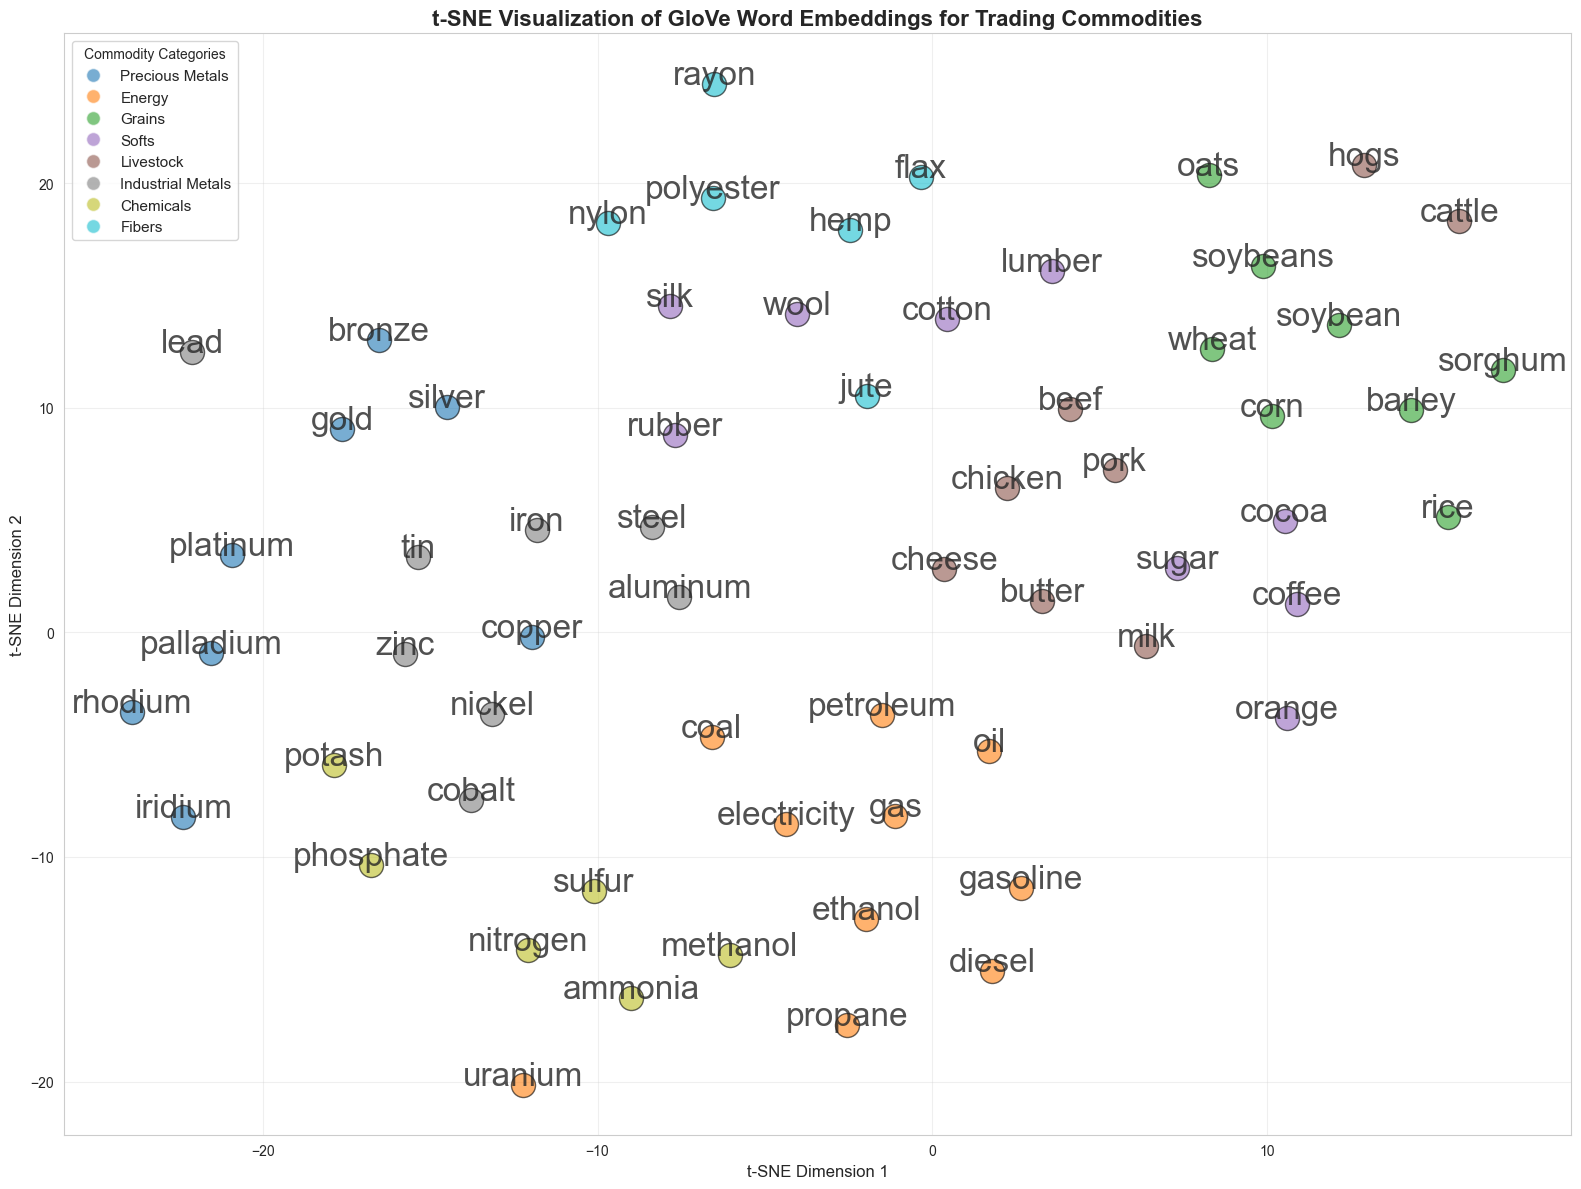

In [7]:
plot_embeddings('t-SNE Visualization of GloVe Word Embeddings for Trading Commodities', valid_words, word_vectors_2d, word_categories)

## **Analyze Clusters**

Let's examine which words cluster together and analyze the semantic relationships.

Create a DataFrame with the words, their categories, and their 2D coordinates to make analysis easier.

In [8]:
# Write your code here
results_df = pd.DataFrame({
    'word': valid_words,
    'category': [word_categories[w] for w in valid_words],
    'x': word_vectors_2d[:, 0],
    'y': word_vectors_2d[:, 1]
})

print("First 10 words and their 2D positions:")
print(results_df.head(10))

First 10 words and their 2D positions:
        word         category          x          y
0       gold  Precious Metals -17.618786   9.057748
1     silver  Precious Metals -14.506663  10.046700
2   platinum  Precious Metals -20.927483   3.432108
3  palladium  Precious Metals -21.539330  -0.941233
4    rhodium  Precious Metals -23.885527  -3.553300
5    iridium  Precious Metals -22.361225  -8.216624
6     copper  Precious Metals -11.970818  -0.215227
7     bronze  Precious Metals -16.521330  13.017466
8        oil           Energy   1.695570  -5.291381
9        gas           Energy  -1.104565  -8.164131


## **TASK 2: Experiment with Different Perplexity Values**

The `perplexity` parameter is crucial in t-SNE. It balances attention between local and global aspects of the data.

**Lower perplexity** (5-15): Focuses on local structure, creates tighter clusters
**Higher perplexity** (30-50): Considers more neighbors, reveals global structure

Let's compare t-SNE results with different perplexity values.

Create visualizations for perplexity values in a 2x2 subplot grid.

Running t-SNE with perplexity=1...


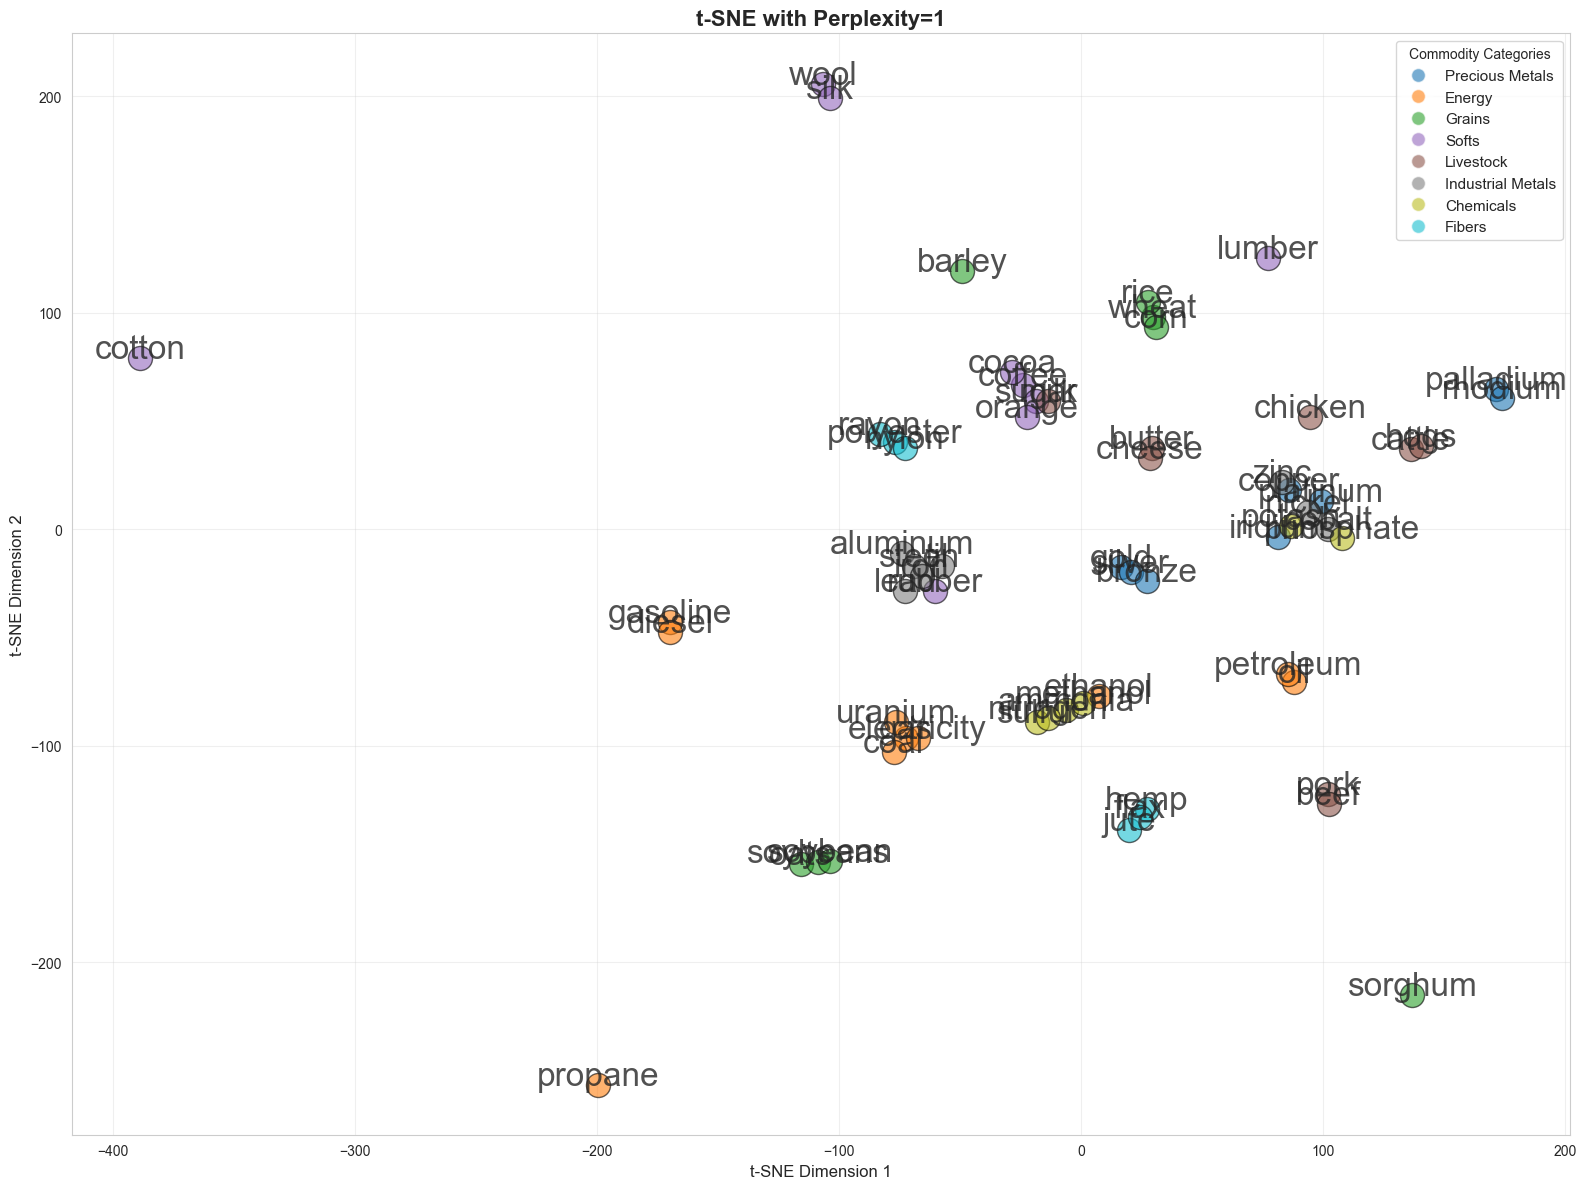

Running t-SNE with perplexity=10...


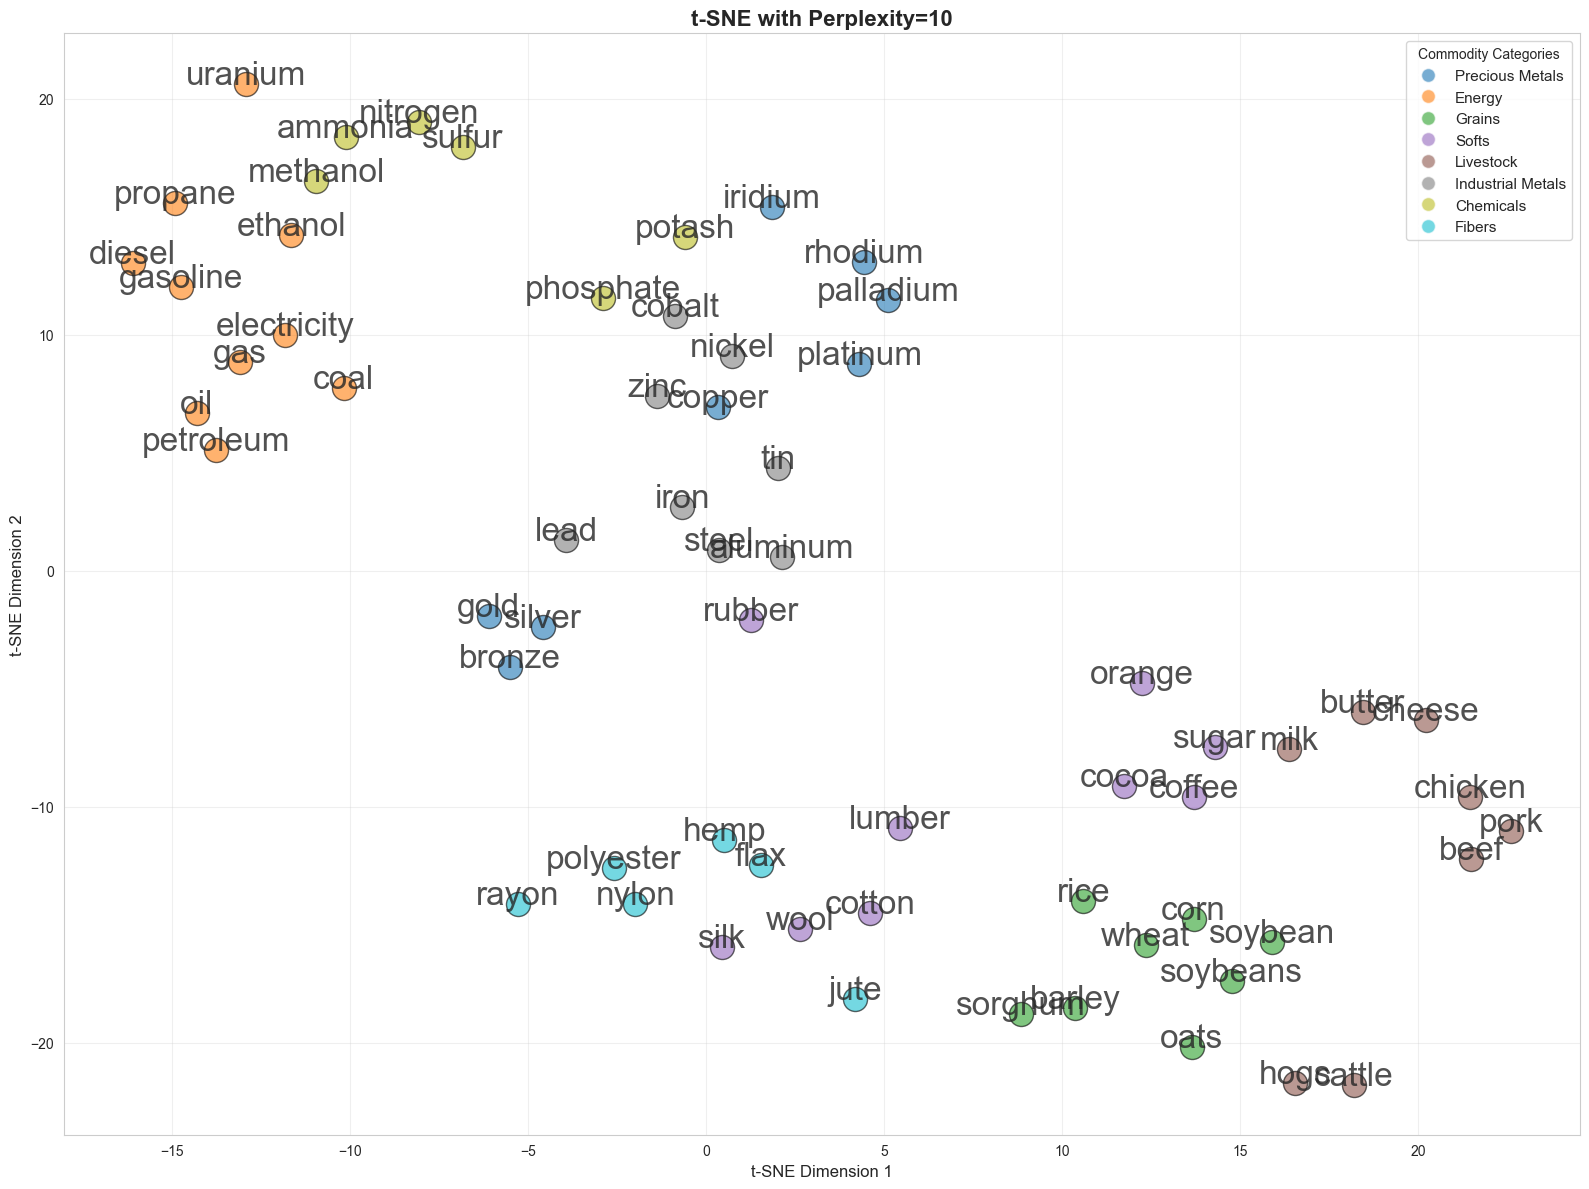

Running t-SNE with perplexity=50...


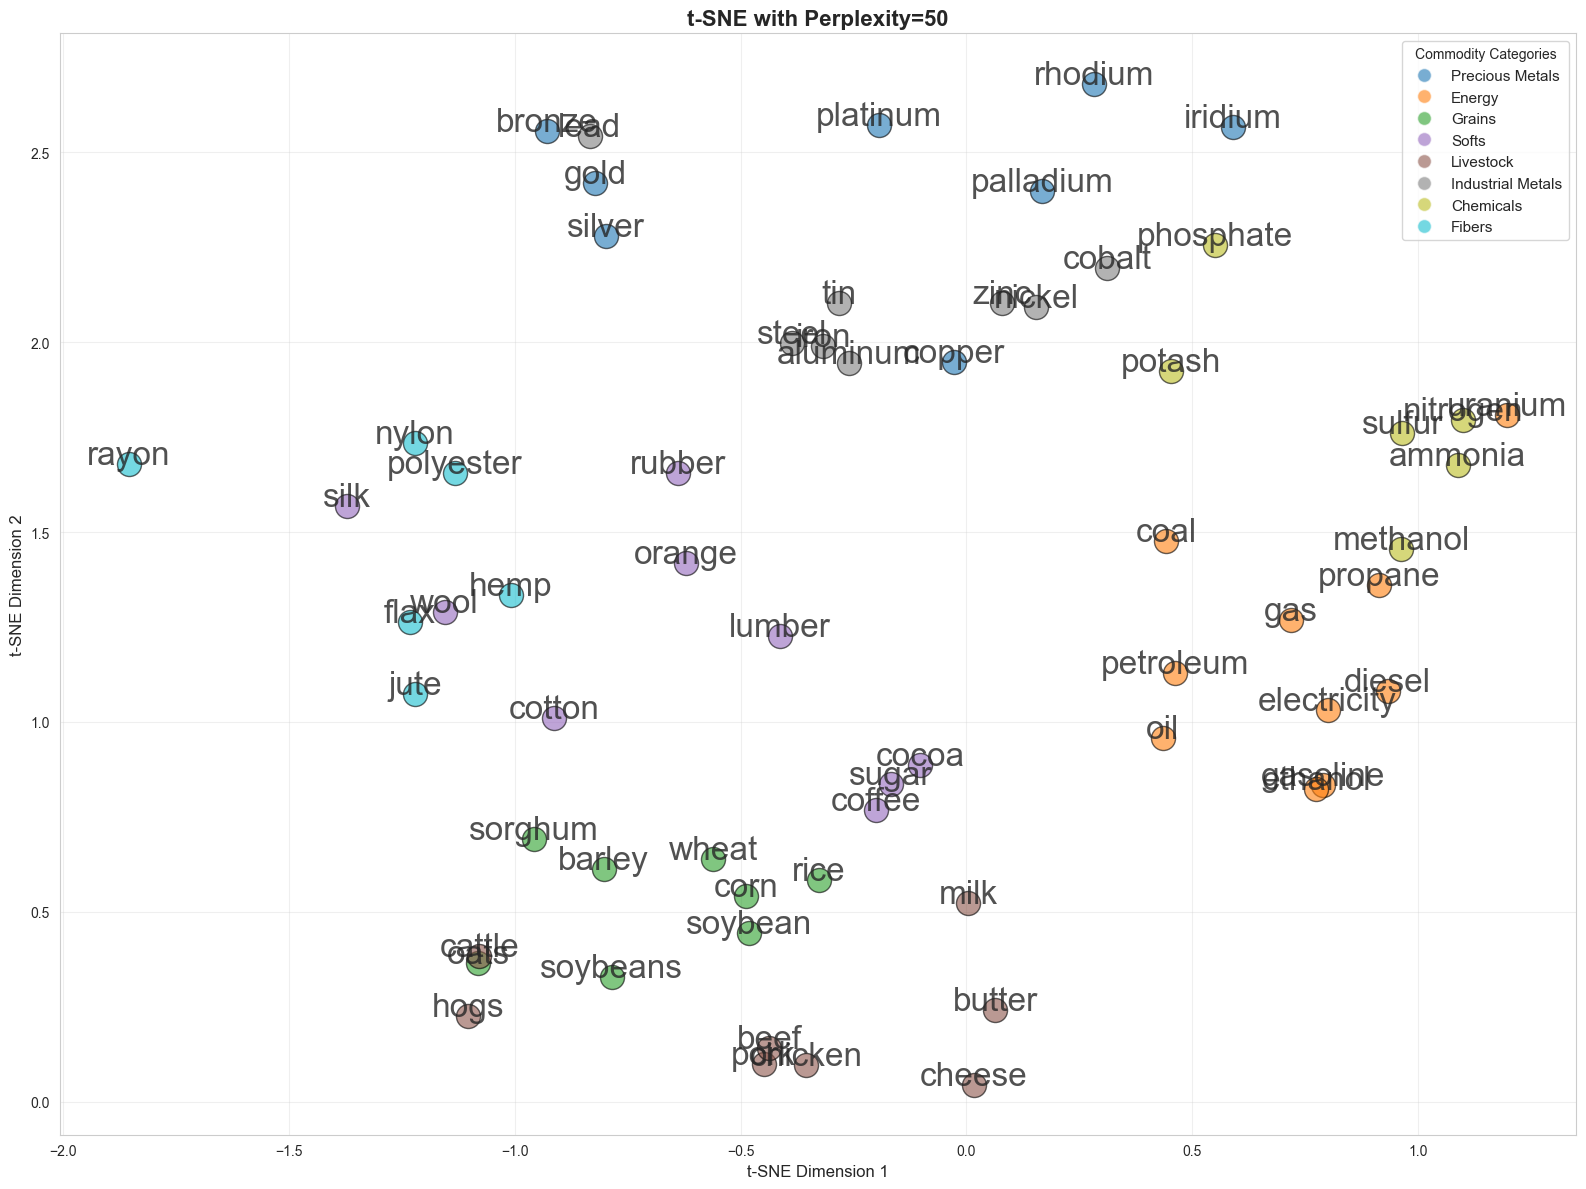


Done!


In [9]:
perplexity_values = [1, 10, 50]

# Write your code here

for idx, perplexity in enumerate(perplexity_values):
    print(f"Running t-SNE with perplexity={perplexity}...")
    
    tsne_temp = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        random_state=42
    )
    
    vectors_2d_temp = tsne_temp.fit_transform(word_vectors)

    plot_embeddings(f't-SNE with Perplexity={perplexity}', valid_words, vectors_2d_temp, word_categories)

print("\nDone!")

## **TASK 3: Compare t-SNE vs PCA**

Let's compare t-SNE with PCA to see the difference between non-linear and linear dimensionality reduction.

- Apply PCA to reduce to 2 dimensions
- Create side-by-side visualizations of PCA and t-SNE

Applying PCA for comparison...
PCA explained variance ratio: [0.17189506 0.1499091 ]
Total variance explained: 0.3218


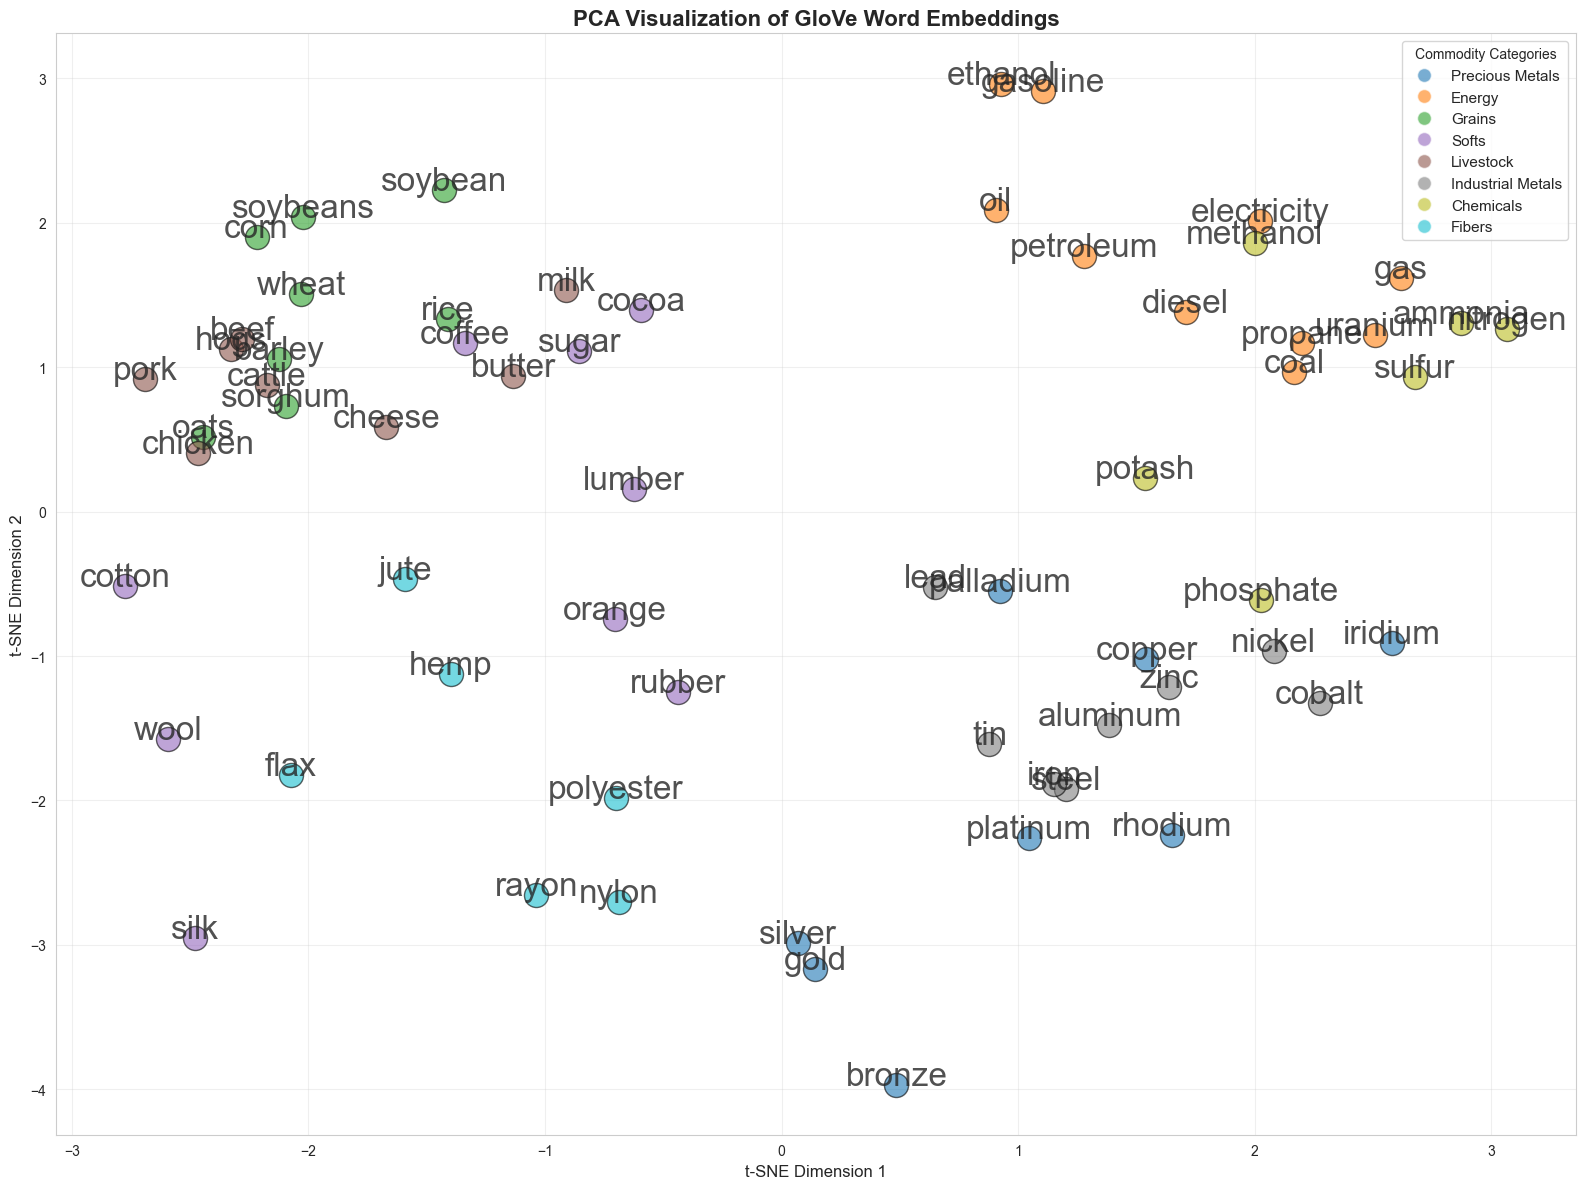

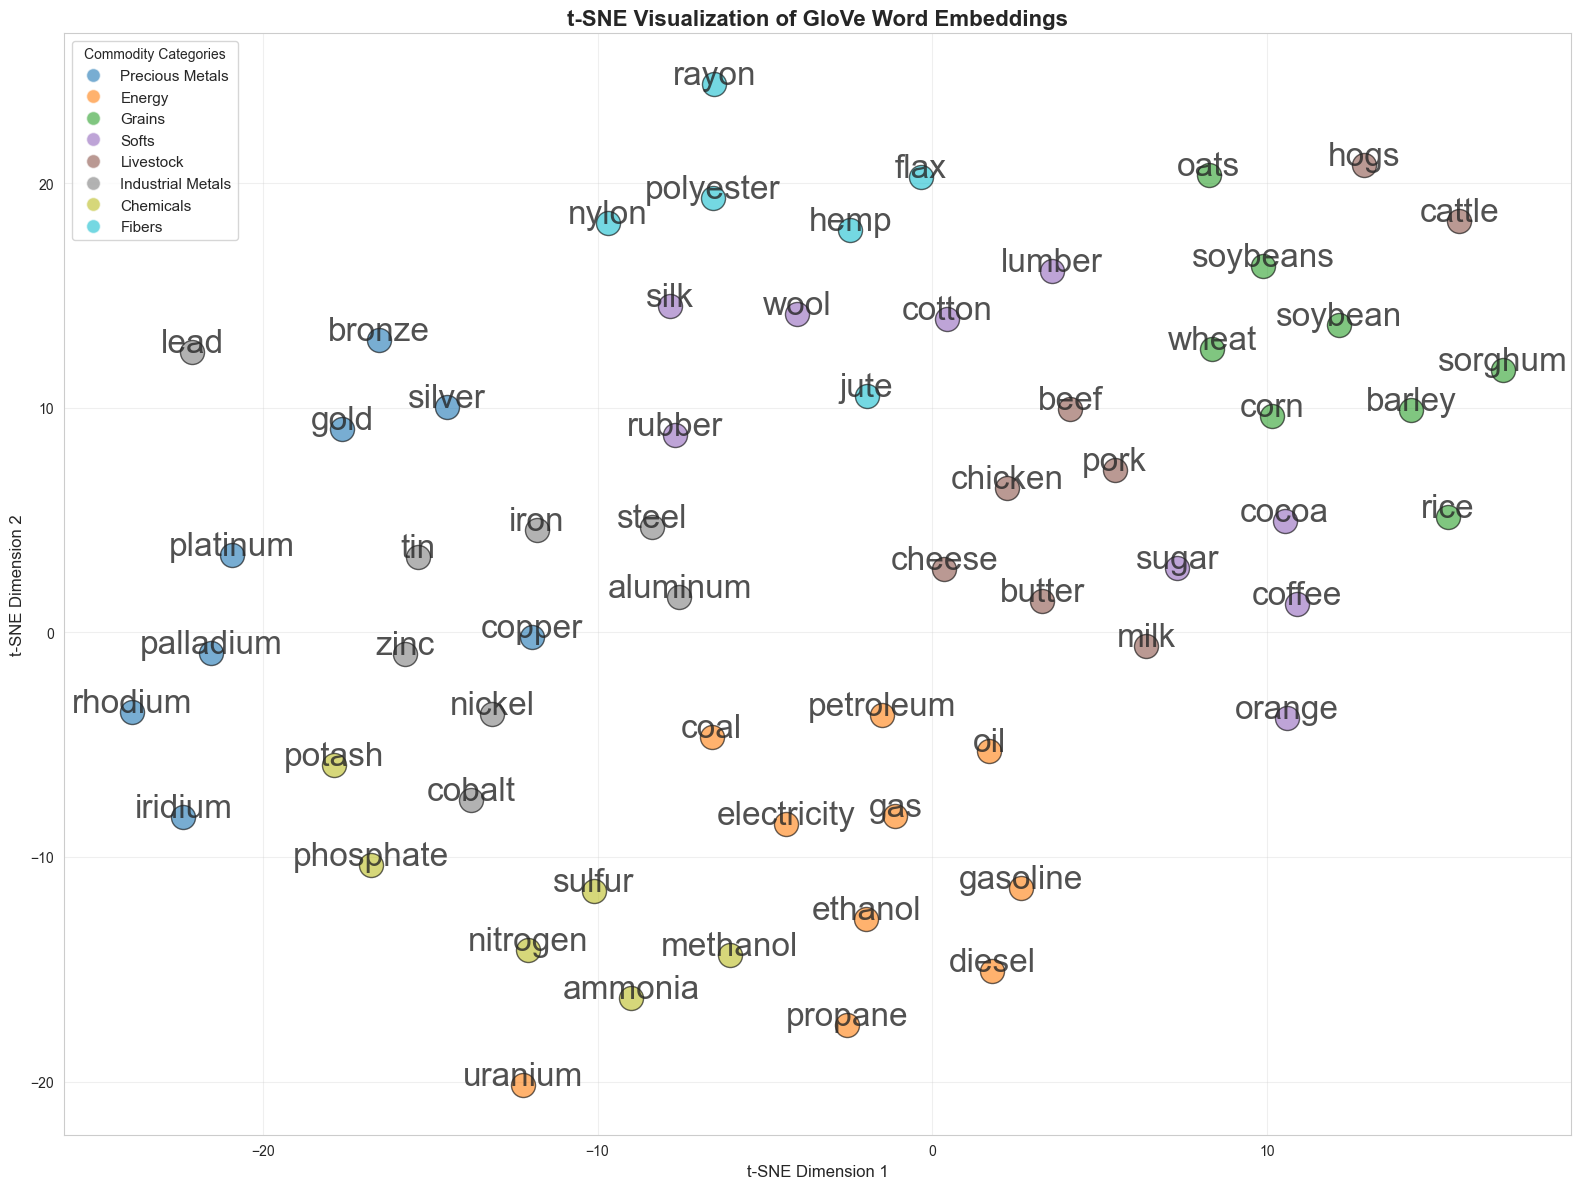

In [10]:
from sklearn.decomposition import PCA

# Write your code here
print("Applying PCA for comparison...")
pca = PCA(n_components=2)
word_vectors_pca = pca.fit_transform(word_vectors)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# PCA plot
plot_embeddings('PCA Visualization of GloVe Word Embeddings', valid_words, word_vectors_pca, word_categories)

# t-SNE plot
plot_embeddings('t-SNE Visualization of GloVe Word Embeddings', valid_words, word_vectors_2d, word_categories)

## **Discussion Questions**

Based on your visualizations, discuss the following:

1. **Clustering Patterns**: Which commodity categories tend to cluster together? Why might this be?
   - Do precious metals cluster separately from industrial metals?
   - Are energy commodities grouped together?
   - What about grains and softs?

2. **Semantic Relationships**: What interesting word relationships do you notice?
   - Are related materials grouped together (e.g., oil and gasoline)?
   - Do metals with similar properties cluster?
   - What about agricultural products?

3. **Effect of Perplexity**: How did different perplexity values affect the visualization?
   - Which perplexity value gave the clearest clusters?
   - What happens at very low or very high perplexity?

4. **PCA vs t-SNE**: What are the key differences you observe?
   - Which method creates clearer clusters?
   - Does PCA preserve the semantic relationships as well?
   - When would you choose one over the other?

## **Write your answers here**

1. **Clustering Patterns**:
   - (TODO: Put answer here)

2. **Semantic Relationships**:
   - (TODO: Put answer here)

3. **Effect of Perplexity**:
   - (TODO: Put answer here)

4. **PCA vs t-SNE**:
   - (TODO: Put answer here)


## **Summary and Key Takeaways**

### What we learned:

1. **Word Embeddings**:
   - GloVe word vectors capture semantic relationships in high-dimensional space
   - Similar words (by meaning or context) have similar vector representations
   - These relationships can be visualized using dimensionality reduction
   - Gensim provides easy access to pre-trained GloVe embeddings

2. **t-SNE for Visualization**:
   - t-SNE is excellent for visualizing high-dimensional data in 2D/3D
   - It preserves local structure (nearby points in high-D stay nearby in low-D)
   - Non-linear method that captures complex relationships
   - Perplexity parameter controls local vs global structure balance

3. **t-SNE vs PCA**:
   - **t-SNE**: Non-linear, preserves local neighborhoods, better for visualization
   - **PCA**: Linear, preserves global structure, faster, better for preprocessing
   - t-SNE typically produces clearer clusters than PCA
   - PCA can explain variance; t-SNE cannot

4. **Practical Considerations**:
   - t-SNE is computationally expensive (slower than PCA)
   - Results can vary with different random seeds
   - Primarily used for visualization, not for feature reduction before ML
   - Perplexity should be chosen based on dataset size (typically 5-50)

5. **When to Use t-SNE**:
   - Visualizing word embeddings, image features, or other high-D data
   - Exploring clustering and relationships in data
   - When you need to present data visually to stakeholders
   - When local structure is more important than global structure

6. **When NOT to Use t-SNE**:
   - As a preprocessing step for machine learning (use PCA instead)
   - When you need to preserve global distances
   - For very large datasets (millions of points) - consider UMAP instead
   - When interpretability of dimensions is needed (PCA components are interpretable)

### Extensions to Explore:

- Try different word categories (e.g., sports terms, emotions, professions)
- Experiment with 3D visualizations using `n_components=3`
- Compare with UMAP (Uniform Manifold Approximation and Projection)
- Explore word arithmetic (e.g., king - man + woman ≈ queen)
- Try higher-dimensional GloVe models (100d, 200d, 300d) via `glove-wiki-gigaword-100`, etc.
- Compare GloVe embeddings with other models like Word2Vec or FastText